# Chapter 1: Introducing Polars

In [ ]:
import polars as pl
pl.__version__  # The book is built with Polars version 1.20.0

## What Is This Thing Called Polars?

### Key Features

### Key Concepts

### Advantages

## Why You Should Use Polars

### Performance

### Usability

### Popularity

### Sustainability

## Polars Compared to Other Data Processing Packages

## Why We Focus on Python Polars

## How This Book Is Organized

## An ETL Showcase

### Extract

#### Import packages

In [1]:
# The command below builds the polars_geo plugin used in this chapter
! cd plugins/polars_geo && uv run maturin develop --release

🍹 Building a mixed python/rust project
🔗 Found pyo3 bindings with abi3 support
🐍 Not using a specific python interpreter
   Compiling proc-macro2 v1.0.92
   Compiling unicode-ident v1.0.14
   Compiling autocfg v1.4.0
   Compiling version_check v0.9.5
   Compiling libm v0.2.11
   Compiling crossbeam-utils v0.8.21
   Compiling libc v0.2.169
   Compiling cfg-if v1.0.0
   Compiling rayon-core v1.12.1          ] 0/339: crossbeam-utils(build.rs)...
   Compiling shlex v1.3.0             ] 1/339: crossbeam-utils(build.rs)...
   Compiling byteorder v1.5.0            ] 2/339: crossbeam-utils(build.rs)...
   Compiling cc v1.2.6                   ] 3/339: crossbeam-utils(build.rs)...
   Compiling ahash v0.8.11               ] 5/339: crossbeam-utils(build.rs)...
   Compiling psm v0.1.24                 ] 6/339: crossbeam-utils(build.rs)...
   Compiling rustversion v1.0.19      ] 7/339: crossbeam-utils(build.rs)...    Building [                           ] 7/339: crossbeam-utils(build.rs)...
   Comp

In [ ]:
# Reset the kernel to make the new plugin available

# The code below will do this automatically when run in IPython
get_ipython().kernel.do_shutdown(restart=True)

In [1]:
import polars as pl  
import polars_geo
from plotnine import *  

#### Download and extract Citi Bike trips

In [ ]:
# It might be needed to install `unzip` first if you're on Linux or macOS.
# Linux:
# sudo apt update && sudo apt install unzip
# macOS:
# brew install unzip
# Windows:
# Download the ZIP file manually and extract it (sorry)

In [2]:
! curl -sO https://s3.amazonaws.com/tripdata/202403-citibike-tripdata.zip
! unzip -o 202403-citibike-tripdata.zip "*.csv" -x "*/*" -d data/citibike/
! rm -f 202403-citibike-tripdata.zip

Archive:  202403-citibike-tripdata.zip
 extracting: data/citibike//202403-citibike-tripdata_3.csv  
 extracting: data/citibike//202403-citibike-tripdata_2.csv  
 extracting: data/citibike//202403-citibike-tripdata_1.csv  
caution: excluded filename not matched:  */*


In [8]:
# Concat the tripdata into one CSV
pl.concat(
    [
        pl.read_csv(f"data/citibike/202403-citibike-tripdata_{num}.csv", ignore_errors=True)
        for num in [1,2,3]
    ]
).write_csv("data/citibike/202403-citibike-tripdata.csv")

#### Read Citi Bike trips into a Polars DataFrame

In [9]:
! wc -l data/citibike/202403-citibike-tripdata.csv
! head -n 6 data/citibike/202403-citibike-tripdata.csv

 2663296 data/citibike/202403-citibike-tripdata.csv
ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
1B6974C51B5788DB,classic_bike,2024-03-14 18:31:26.739,2024-03-14 18:53:08.260,1 Ave & E 38 St,6230.02,W 76 St & Columbus Ave,7281.09,40.746202,-73.971822,40.7801839724239,-73.97728532552719,member
18FA2461899D63BD,classic_bike,2024-03-03 20:58:49.618,2024-03-03 21:19:58.899,Park Ave & E 124 St,7682.01,W 76 St & Columbus Ave,7281.09,40.8045555,-73.9396861,40.7801839724239,-73.97728532552719,member
19472F3D2F814B4A,electric_bike,2024-03-03 11:54:48.509,2024-03-03 12:11:19.163,W 34 St & Hudson Blvd E,6535.04,North Moore St & Greenwich St,5470.12,40.75516719072139,-74.00059908628464,40.72019521437465,-74.0103006362915,member
EE6390136F5EDF27,electric_bike,2024-03-05 11:37:20.593,2024-03-05 11:41:53.848,E 9 St & 5 Ave,5872.1,Ave A & E 11 St,5703.13,40.73275887045087,-73.995816707611

In [10]:
trips = pl.read_csv(  
    "data/citibike/202403-citibike-tripdata.csv",
    try_parse_dates=True,
    schema_overrides={
        "start_station_id": pl.String,
        "end_station_id": pl.String,
    },
).sort(  
    "started_at"
)

trips.height

2663295

In [11]:
print(trips[:, :4])
print(trips[:, 4:8])
print(trips[:, 8:])

shape: (2_663_295, 4)
┌──────────────────┬───────────────┬─────────────────────────┬─────────────────────────┐
│ ride_id          ┆ rideable_type ┆ started_at              ┆ ended_at                │
│ ---              ┆ ---           ┆ ---                     ┆ ---                     │
│ str              ┆ str           ┆ datetime[μs]            ┆ datetime[μs]            │
╞══════════════════╪═══════════════╪═════════════════════════╪═════════════════════════╡
│ 9EC2AD5F3F8C8B57 ┆ classic_bike  ┆ 2024-02-29 00:20:27.570 ┆ 2024-03-01 01:20:22.196 │
│ C76D82D96516BDC2 ┆ classic_bike  ┆ 2024-02-29 07:54:34.223 ┆ 2024-03-01 08:54:12.611 │
│ B4C73C958C65FEA6 ┆ electric_bike ┆ 2024-02-29 08:47:09.664 ┆ 2024-03-01 09:47:02.393 │
│ E23F7822B3D53E2A ┆ classic_bike  ┆ 2024-02-29 09:57:07.150 ┆ 2024-03-01 10:57:00.848 │
│ B0B6437C50C3AB3E ┆ electric_bike ┆ 2024-02-29 10:29:41.981 ┆ 2024-03-01 11:29:21.539 │
│ …                ┆ …             ┆ …                       ┆ …                       │

#### Read in neighborhoods from GeoJSON

In [13]:
! python3 -m json.tool data/citibike/nyc-neighborhoods.geojson

{
    "type": "FeatureCollection",
    "crs": {
        "type": "name",
        "properties": {
            "name": "urn:ogc:def:crs:OGC:1.3:CRS84"
        }
    },
    "features": [
        {
            "type": "Feature",
            "properties": {
                "neighborhood": "Allerton",
                "boroughCode": "2",
                "borough": "Bronx",
                "X.id": "http://nyc.pediacities.com/Resource/Neighborhood/Allerton"
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [
                            -73.84859700000018,
                            40.871670000000115
                        ],
                        [
                            -73.84582253683678,
                            40.870239076236174
                        ],
                        [
                            -73.85455918463374,
                            40.85995383576425
 

In [14]:
neighborhoods = (
    pl.read_json("data/citibike/nyc-neighborhoods.geojson")
    .select("features")
    .explode("features")  
    .unnest("features")
    .unnest("properties")
    .select("neighborhood", "borough", "geometry")
    .unnest("geometry")
    .with_columns(polygon=pl.col("coordinates").list.first())
    .select("neighborhood", "borough", "polygon")
    .filter(pl.col("borough") != "Staten Island")  
    .sort("neighborhood")
)

neighborhoods

neighborhood,borough,polygon
str,str,list[list[f64]]
"""Allerton""","""Bronx""","[[-73.848597, 40.87167], [-73.845823, 40.870239], … [-73.848597, 40.87167]]"
"""Alley Pond Park""","""Queens""","[[-73.743333, 40.738883], [-73.743714, 40.739403], … [-73.743333, 40.738883]]"
"""Arverne""","""Queens""","[[-73.789535, 40.599972], [-73.789541, 40.599944], … [-73.789535, 40.599972]]"
"""Astoria""","""Queens""","[[-73.901603, 40.76777], [-73.902696, 40.766889], … [-73.901603, 40.76777]]"
"""Bath Beach""","""Brooklyn""","[[-73.99381, 40.60195], [-73.99962, 40.596469], … [-73.99381, 40.60195]]"
…,…,…
"""Williamsburg""","""Brooklyn""","[[-73.957572, 40.725097], [-73.952998, 40.722253], … [-73.957572, 40.725097]]"
"""Windsor Terrace""","""Brooklyn""","[[-73.980061, 40.660753], [-73.979878, 40.660711], … [-73.980061, 40.660753]]"
"""Woodhaven""","""Queens""","[[-73.86233, 40.695962], [-73.856544, 40.697075], … [-73.86233, 40.695962]]"


### Bonus: Visualizing Neighborhoods and Stations

In [19]:
neighborhoods_coords = (
    neighborhoods.with_row_index("id")
    .explode("polygon")
    .with_columns(
        lon=pl.col("polygon").list.first(),
        lat=pl.col("polygon").list.last(),
    )
    .drop("polygon")
)

neighborhoods_coords

id,neighborhood,borough,lon,lat
u32,str,str,f64,f64
0,"""Allerton""","""Bronx""",-73.848597,40.87167
0,"""Allerton""","""Bronx""",-73.845823,40.870239
0,"""Allerton""","""Bronx""",-73.854559,40.859954
0,"""Allerton""","""Bronx""",-73.854665,40.859586
0,"""Allerton""","""Bronx""",-73.856389,40.857594
…,…,…,…,…
257,"""Woodside""","""Queens""",-73.910618,40.755476
257,"""Woodside""","""Queens""",-73.90907,40.757565
257,"""Woodside""","""Queens""",-73.907828,40.756999


In [20]:
stations = (
    trips.group_by(station=pl.col("start_station_name"))
    .agg(  
        lon=pl.col("start_lng").median(),
        lat=pl.col("start_lat").median(),
    )
    .sort("station")
    .drop_nulls()
)
stations

station,lon,lat
str,f64,f64
"""1 Ave & E 110 St""",-73.9383,40.792327
"""1 Ave & E 16 St""",-73.981656,40.732219
"""1 Ave & E 18 St""",-73.980544,40.733812
"""1 Ave & E 30 St""",-73.975361,40.741444
"""1 Ave & E 38 St""",-73.971822,40.746202
…,…,…
"""Wyckoff Ave & Stanhope St""",-73.917775,40.703545
"""Wyckoff St & 3 Ave""",-73.982586,40.682755
"""Wythe Ave & Metropolitan Ave""",-73.963198,40.716887


Matplotlib is building the font cache; this may take a moment.


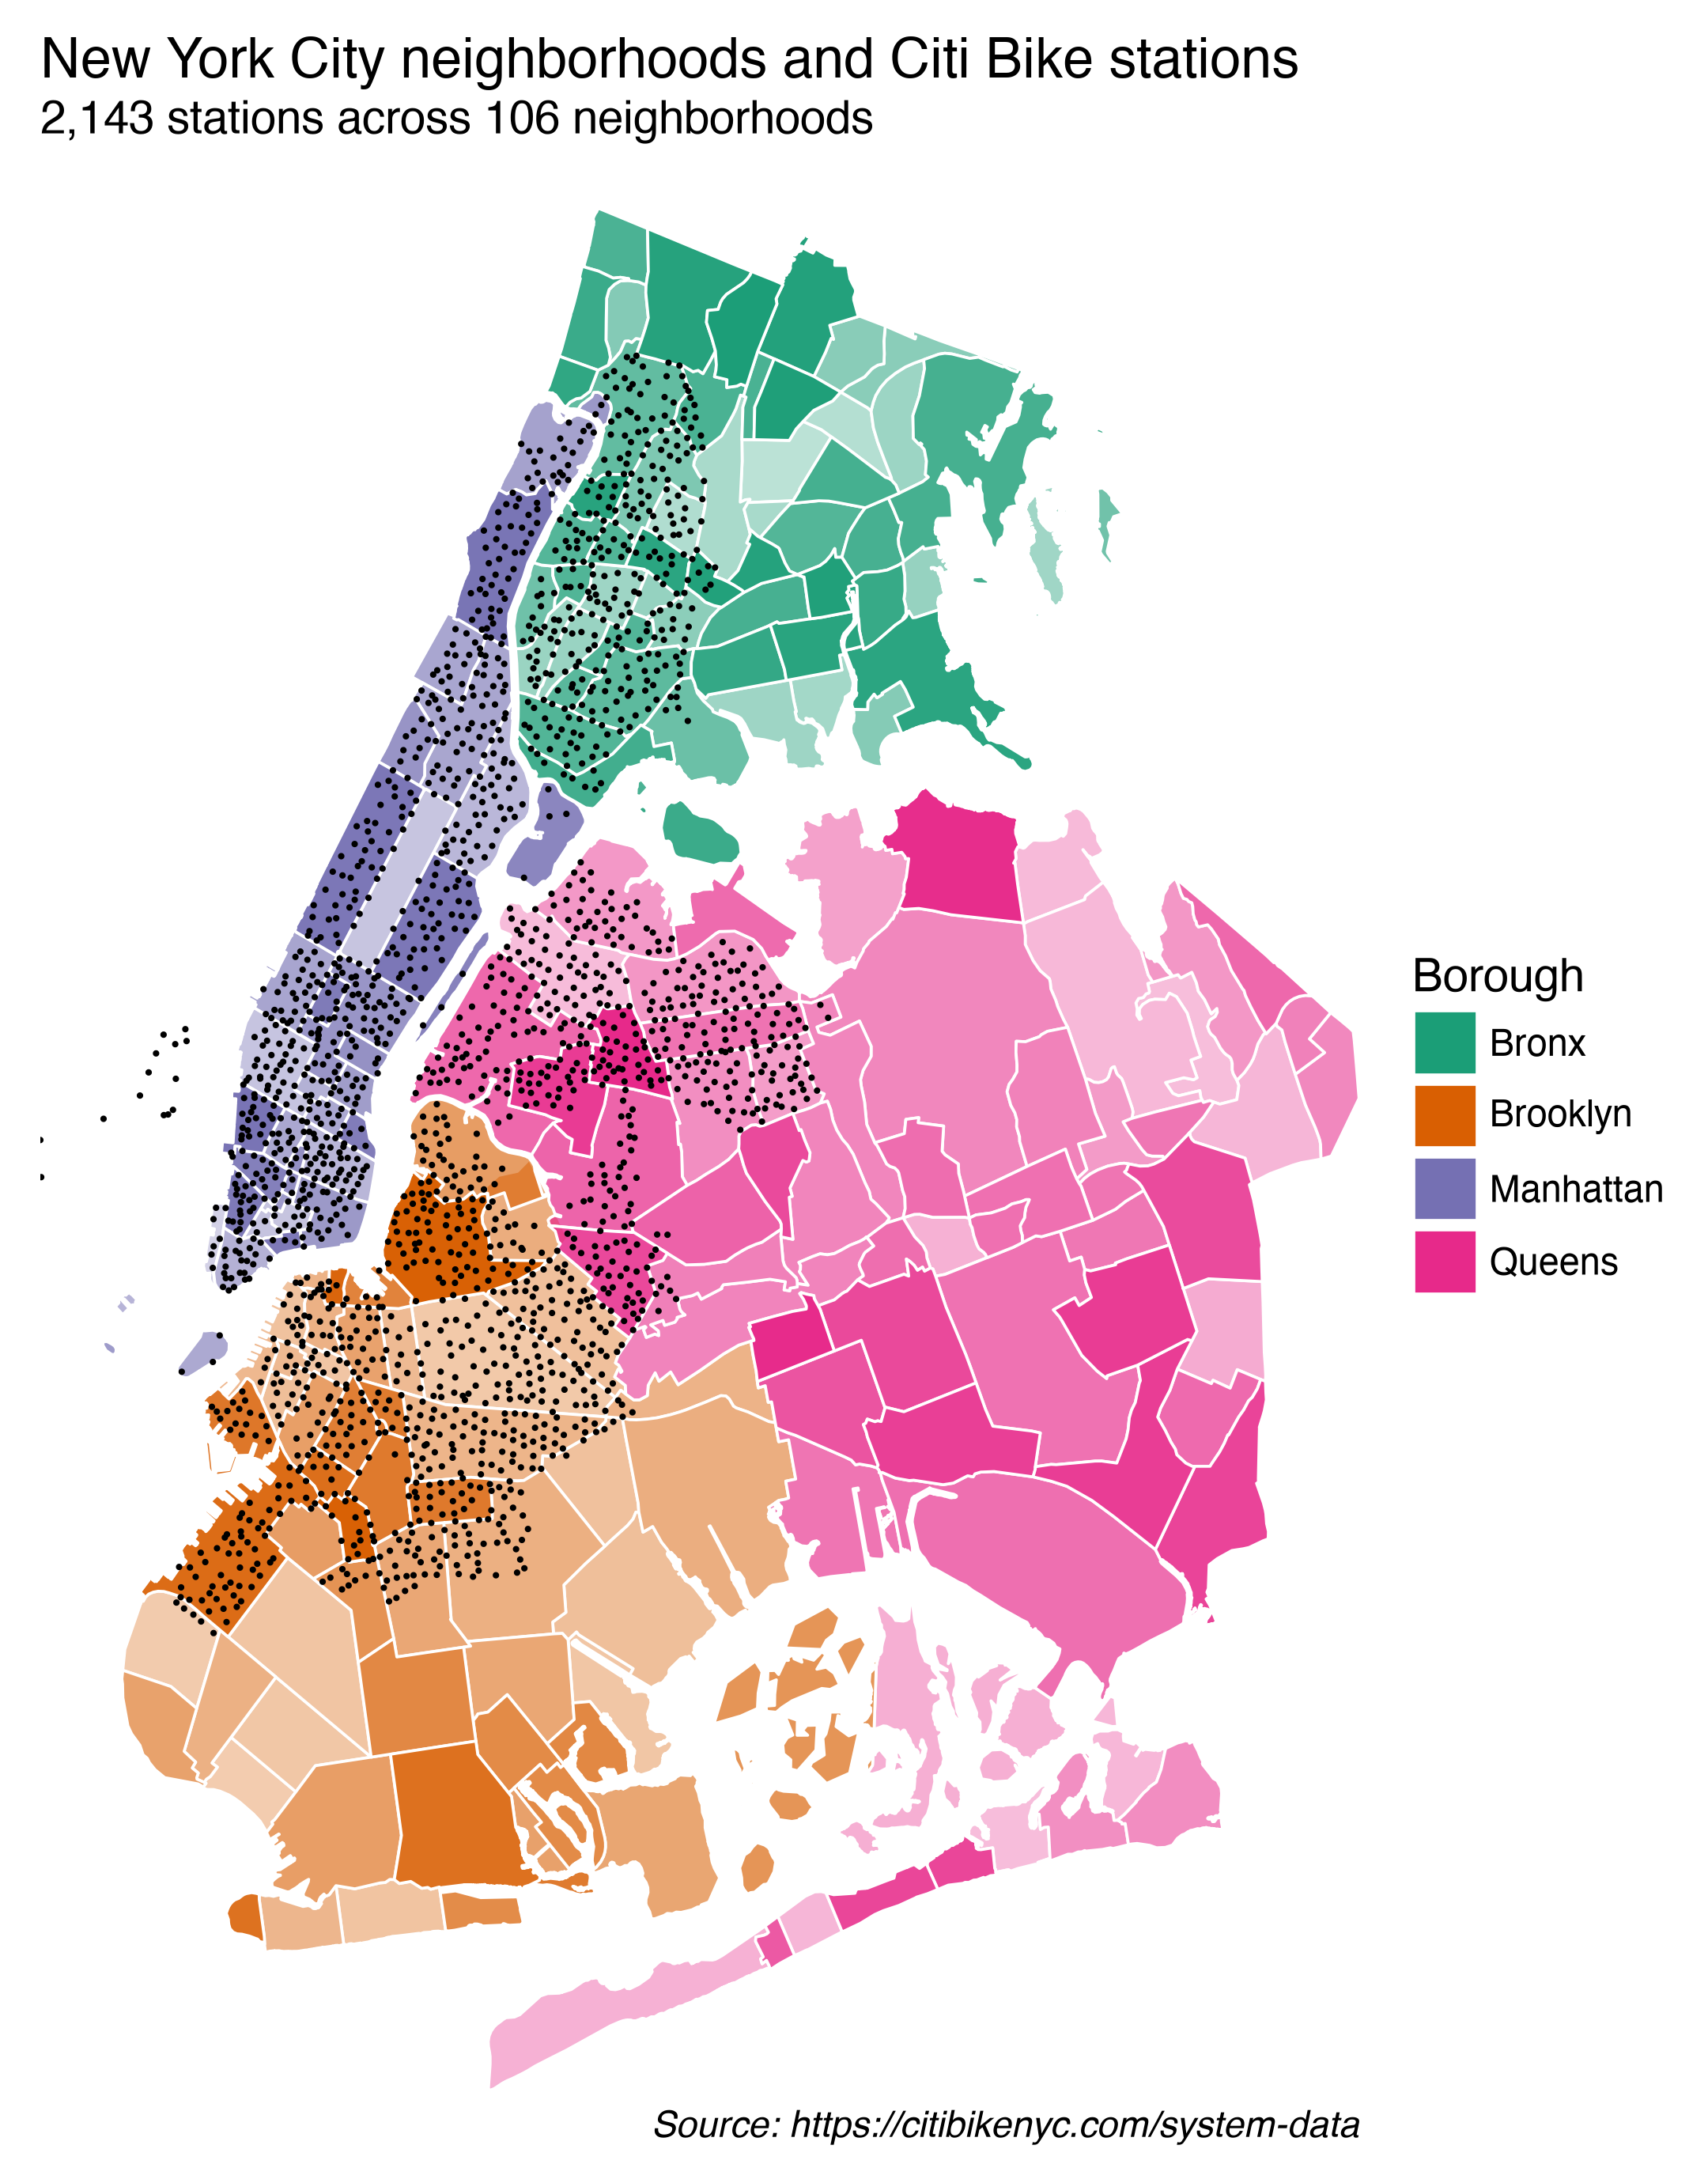

In [21]:
(
    ggplot(neighborhoods_coords, aes(x="lon", y="lat", group="id"))
    + geom_polygon(aes(alpha="neighborhood", fill="borough"), color="white")
    + geom_point(stations, size=0.1)
    + scale_x_continuous(expand=(0, 0))
    + scale_y_continuous(expand=(0, 0, 0, 0.01))
    + scale_alpha_ordinal(range=(0.3, 1))
    + scale_fill_brewer(type="qual", palette=2)
    + guides(alpha=False)
    + labs(
        title="New York City neighborhoods and Citi Bike stations",
        subtitle="2,143 stations across 106 neighborhoods",
        caption="Source: https://citibikenyc.com/system-data",
        fill="Borough",
    )
    + theme_void(base_size=14)
    + theme(
        dpi=300,
        figure_size=(7, 9),
        plot_background=element_rect(fill="white", color="white"),
        plot_caption=element_text(style="italic"),
        plot_margin=0.01,
        plot_title=element_text(ha="left"),
    )
)

### Transform

#### Clean up columns

In [22]:
trips = trips.select(
    bike_type=pl.col("rideable_type")
    .str.split("_")
    .list.get(0)
    .cast(pl.Categorical),  
    rider_type=pl.col("member_casual").cast(pl.Categorical),
    datetime_start=pl.col("started_at"),
    datetime_end=pl.col("ended_at"),
    station_start=pl.col("start_station_name"),
    station_end=pl.col("end_station_name"),
    lon_start=pl.col("start_lng"),
    lat_start=pl.col("start_lat"),
    lon_end=pl.col("end_lng"),
    lat_end=pl.col("end_lat"),
).with_columns(  
    duration=(pl.col("datetime_end") - pl.col("datetime_start"))
)

trips.columns

['bike_type',
 'rider_type',
 'datetime_start',
 'datetime_end',
 'station_start',
 'station_end',
 'lon_start',
 'lat_start',
 'lon_end',
 'lat_end',
 'duration']

#### Clean up rows

In [23]:
trips = (
    trips.drop_nulls()
    .filter(  
        (pl.col("datetime_start") >= pl.date(2024, 3, 1))
        & (pl.col("datetime_end") < pl.date(2024, 4, 1))
    )
    .filter(
        ~(
            (pl.col("station_start") == pl.col("station_end"))
            & (pl.col("duration").dt.total_seconds() < 5 * 60)
        )
    )
)

trips.height

2638969

#### Add trip distance

In [24]:
trips = trips.with_columns(
    distance=pl.concat_list("lon_start", "lat_start").geo.haversine_distance(
        pl.concat_list("lon_end", "lat_end")
    )
    / 1000  
)

trips.select(
    "lon_start",
    "lon_end",
    "lat_start",
    "lat_end",
    "distance",
    "duration",
)

lon_start,lon_end,lat_start,lat_end,distance,duration
f64,f64,f64,f64,f64,duration[μs]
-73.995208,-74.007319,40.749653,40.707065,4.8443,27m 36s 805ms
-73.896447,-73.927311,40.816343,40.810893,2.667176,9m 25s 264ms
-73.988557,-73.989186,40.746201,40.742869,0.374287,3m 29s 483ms
-73.995208,-74.013219,40.749653,40.705945,5.09153,30m 56s 960ms
-73.957462,-73.979881,40.690648,40.668663,3.090373,11m 32s 483ms
…,…,…,…,…,…
-73.974552,-73.977724,40.729848,40.729387,0.272175,1m 41s 374ms
-73.971092,-73.965269,40.763505,40.763126,0.492269,3m 30s 363ms
-73.959621,-73.955151,40.808625,40.81,0.406138,1m 46s 248ms


#### Add borough and neighborhood

In [25]:
stations = (
    stations.with_columns(point=pl.concat_list("lon", "lat"))
    .join(neighborhoods, how="cross")
    .with_columns(
        in_neighborhood=pl.col("point").geo.point_in_polygon(pl.col("polygon"))
    )
    .filter(pl.col("in_neighborhood"))
    .unique("station")
    .select(
        "station",
        "borough",
        "neighborhood",
    )
)

stations

station,borough,neighborhood
str,str,str
"""1 Ave & E 110 St""","""Manhattan""","""East Harlem"""
"""1 Ave & E 16 St""","""Manhattan""","""Stuyvesant Town"""
"""1 Ave & E 18 St""","""Manhattan""","""Stuyvesant Town"""
"""1 Ave & E 30 St""","""Manhattan""","""Kips Bay"""
"""1 Ave & E 38 St""","""Manhattan""","""Murray Hill"""
…,…,…
"""Wyckoff Ave & Stanhope St""","""Brooklyn""","""Bushwick"""
"""Wyckoff St & 3 Ave""","""Brooklyn""","""Gowanus"""
"""Wythe Ave & Metropolitan Ave""","""Brooklyn""","""Williamsburg"""


In [26]:
trips = (
    trips.join(
        stations.select(pl.all().name.suffix("_start")), on="station_start"
    )
    .join(stations.select(pl.all().name.suffix("_end")), on="station_end")
    .select(
        "bike_type",
        "rider_type",
        "datetime_start",
        "datetime_end",
        "duration",
        "station_start",
        "station_end",
        "neighborhood_start",
        "neighborhood_end",
        "borough_start",
        "borough_end",
        "lat_start",
        "lon_start",
        "lat_end",
        "lon_end",
        "distance",
    )
)

In [27]:
print(trips[:, :4])
print(trips[:, 4:7])
print(trips[:, 7:11])
print(trips[:, 11:])

shape: (2_638_767, 4)
┌───────────┬────────────┬─────────────────────────┬─────────────────────────┐
│ bike_type ┆ rider_type ┆ datetime_start          ┆ datetime_end            │
│ ---       ┆ ---        ┆ ---                     ┆ ---                     │
│ cat       ┆ cat        ┆ datetime[μs]            ┆ datetime[μs]            │
╞═══════════╪════════════╪═════════════════════════╪═════════════════════════╡
│ electric  ┆ member     ┆ 2024-03-01 00:00:02.490 ┆ 2024-03-01 00:27:39.295 │
│ electric  ┆ member     ┆ 2024-03-01 00:00:04.120 ┆ 2024-03-01 00:09:29.384 │
│ electric  ┆ casual     ┆ 2024-03-01 00:00:05.209 ┆ 2024-03-01 00:03:34.692 │
│ classic   ┆ member     ┆ 2024-03-01 00:00:05.259 ┆ 2024-03-01 00:31:02.219 │
│ electric  ┆ member     ┆ 2024-03-01 00:00:09.837 ┆ 2024-03-01 00:11:42.320 │
│ …         ┆ …          ┆ …                       ┆ …                       │
│ classic   ┆ member     ┆ 2024-03-31 23:55:29.002 ┆ 2024-03-31 23:57:10.376 │
│ classic   ┆ member     ┆ 202

### Bonus: Visualizing Daily Trips per Borough

In [28]:
trips_per_day = trips.group_by_dynamic(
    "datetime_start", group_by="borough_start", every="1d"
).agg(num_trips=pl.len())

trips_per_day

borough_start,datetime_start,num_trips
str,datetime[μs],u32
"""Bronx""",2024-03-01 00:00:00,2748
"""Bronx""",2024-03-02 00:00:00,1010
"""Bronx""",2024-03-03 00:00:00,3084
"""Bronx""",2024-03-04 00:00:00,3072
"""Bronx""",2024-03-05 00:00:00,1623
…,…,…
"""Manhattan""",2024-03-27 00:00:00,61357
"""Manhattan""",2024-03-28 00:00:00,35325
"""Manhattan""",2024-03-29 00:00:00,61447


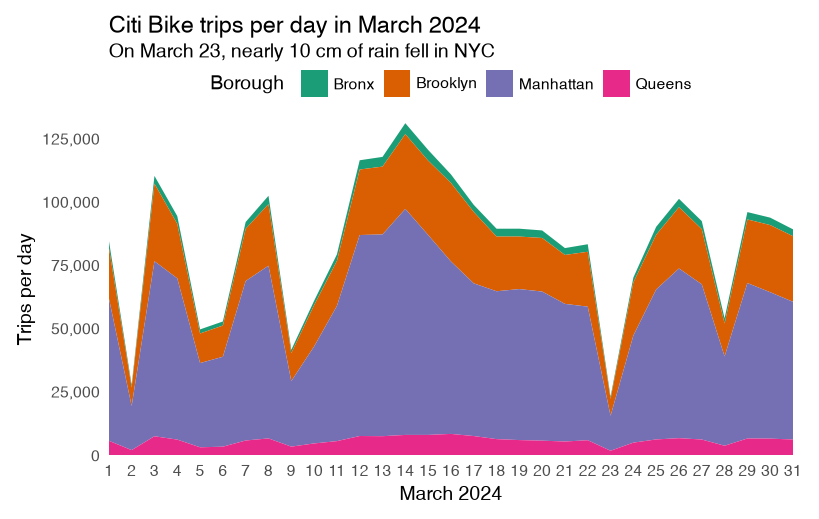

In [29]:
from mizani.labels import label_comma

(
    ggplot(
        trips_per_day,
        aes(x="datetime_start", y="num_trips", fill="borough_start"),
    )
    + geom_area()
    + scale_fill_brewer(type="qual", palette=2)
    + scale_x_datetime(date_labels="%-d", date_breaks="1 day", expand=(0, 0))
    + scale_y_continuous(labels=label_comma(), expand=(0, 0))
    + labs(
        x="March 2024",
        fill="Borough",
        y="Trips per day",
        title="Citi Bike trips per day in March 2024",
        subtitle="On March 23, nearly 10 cm of rain fell in NYC",
    )
    + theme_tufte(base_size=14)
    + theme(
        axis_ticks_major=element_line(color="white"),
        figure_size=(8, 5),
        legend_position="top",
        plot_background=element_rect(fill="white", color="white"),
        plot_caption=element_text(style="italic"),
        plot_title=element_text(ha="left"),
    )
)

### Load

#### Write partitions

In [ ]:
trips_parts = (
    trips.sort("datetime_start")
    .with_columns(date=pl.col("datetime_start").dt.date().cast(pl.String))
    .partition_by(["date"], as_dict=True, include_key=False)
)

for key, df in trips_parts.items():
    df.write_parquet(f"data/citibike/trips-{key[0]}.parquet")

#### Verify

In [ ]:
! ls -1 data/citibike/*.parquet

In [ ]:
pl.read_parquet("data/citibike/*.parquet").height

### Bonus: Becoming Faster by Being Lazy

In [ ]:
trips = (
    pl.scan_csv(
        "data/citibike/202403-citibike-tripdata.csv",  
        try_parse_dates=True,
        schema_overrides={
            "start_station_id": pl.String,
            "end_station_id": pl.String,
        },
    )
    .select(
        bike_type=pl.col("rideable_type").str.split("_").list.get(0),
        rider_type=pl.col("member_casual"),
        datetime_start=pl.col("started_at"),
        datetime_end=pl.col("ended_at"),
        station_start=pl.col("start_station_name"),
        station_end=pl.col("end_station_name"),
        lon_start=pl.col("start_lng"),
        lat_start=pl.col("start_lat"),
        lon_end=pl.col("end_lng"),
        lat_end=pl.col("end_lat"),
    )
    .with_columns(duration=(pl.col("datetime_end") - pl.col("datetime_start")))
    .drop_nulls()
    .filter(
        ~(
            (pl.col("station_start") == pl.col("station_end"))
            & (pl.col("duration").dt.total_seconds() < 5 * 60)
        )
    )
    .with_columns(
        distance=pl.concat_list(
            "lon_start", "lat_start"
        ).geo.haversine_distance(pl.concat_list("lon_end", "lat_end"))
        / 1000
    )
).collect()  

neighborhoods = (
    pl.read_json("data/citibike/nyc-neighborhoods.geojson")
    .lazy()  
    .select("features")
    .explode("features")
    .unnest("features")
    .unnest("properties")
    .select("neighborhood", "borough", "geometry")
    .unnest("geometry")
    .with_columns(polygon=pl.col("coordinates").list.first())
    .select("neighborhood", "borough", "polygon")
    .sort("neighborhood")
    .filter(pl.col("borough") != "Staten Island")
)

stations = (
    trips.lazy()
    .group_by(station=pl.col("station_start"))
    .agg(
        lat=pl.col("lat_start").median(),
        lon=pl.col("lon_start").median(),
    )
    .with_columns(point=pl.concat_list("lon", "lat"))
    .drop_nulls()
    .join(neighborhoods, how="cross")
    .with_columns(
        in_neighborhood=pl.col("point").geo.point_in_polygon(pl.col("polygon"))
    )
    .filter(pl.col("in_neighborhood"))
    .unique("station")
    .select(
        pl.col("station"),
        pl.col("borough"),
        pl.col("neighborhood"),
    )
).collect()

trips = (
    trips.join(
        stations.select(pl.all().name.suffix("_start")), on="station_start"
    )
    .join(stations.select(pl.all().name.suffix("_end")), on="station_end")
    .select(
        "bike_type",
        "rider_type",
        "datetime_start",
        "datetime_end",
        "duration",
        "station_start",
        "station_end",
        "neighborhood_start",
        "neighborhood_end",
        "borough_start",
        "borough_end",
        "lat_start",
        "lon_start",
        "lat_end",
        "lon_end",
        "distance",
    )
)

trips.height

In [32]:
pl.read_csv('data/citibike/*.csv', ignore_errors=True).write_csv('data/citibike/202403-citibike-tripdata.csv')

## Takeaways